<div align="center">

# Prédiction de la souscription d'un dépôt à terme  

## Entraînement du modèle

<img src="https://raw.githubusercontent.com/komiadok/termdepositforecast/main/cover_image.jpg" width="500"/>

</div>

<div style="background-color:#008080; color:white; padding:15px; border-radius:8px; font-weight:bold; font-size:16px;">
📚 Chargement des librairies
</div>

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer, LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, brier_score_loss, log_loss
)
from sklearn.calibration import calibration_curve

<div style="background-color:#008080; color:white; padding:15px; border-radius:8px; font-weight:bold; font-size:16px;">
🗃️ Partie 1 : Importation des données
</div>

In [2]:
# Chargement du dataset
data = pd.read_csv('../data/raw/bank-additional-full.csv', sep = ';')
print(f'Taille du dataframe : {data.shape}')

# Aperçu du dataset
data.head()

Taille du dataframe : (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
# Définition du chemin où se trouve utils
import sys
sys.path.append('../pipelines/')  

# Importation de la classe
from preprocess import DataCleaningPipeline

In [4]:
# Instanciation du pipeline
pipeline = DataCleaningPipeline(
    min_age=18,
    max_duration=300,
    max_calls=5,
    output_dir='../data/outputs'
)

# Transformation du DataFrame
cleaned_data = pipeline.fit_transform(data)
print(f'Taille du dataframe : {cleaned_data.shape}')

# Vérification des premières lignes
cleaned_data.head()

Taille du dataframe : (41183, 31)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,missing_job,missing_marital,missing_education,missing_default,missing_housing,missing_loan,outlier_duration,outlier_campaign,outlier_previous,never_contacted
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,False,False,False,False,False,False,False,False,False,True
1,57,services,married,high.school,missing,no,no,telephone,may,mon,...,False,False,False,True,False,False,False,False,False,True
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,False,False,False,False,False,False,False,False,False,True
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,False,False,False,False,False,False,False,False,False,True
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,False,False,False,False,False,False,True,False,False,True


<div style="background-color:#008080; color:white; padding:15px; border-radius:8px; font-weight:bold; font-size:16px;">
🛠️ Partie 2 : Prétraitement des données et entraînement du modèle
</div>

In [5]:
# Variables numériques à standardiser
numerical_features = ['age', 'campaign', 'pdays', 'previous', 'euribor3m', 'cons.price.idx', 'cons.conf.idx']

# Variables catégorielles à encoder
onehot_features = ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'poutcome'] # catégorielles sans ordre
ordinal_features = ['education'] # catégorielles avec ordre

# Variables temporelles à encoder
cyclic_features = ['month', 'day_of_week'] # sin/cos encoding

# Variables indicatrices
indicator_features = [col for col in cleaned_data.columns if col.startswith('missing') or col.startswith('outlier')]

# Ajout de la variable never_contacted
if 'never_contacted' in cleaned_data.columns:
    indicator_features.append('never_contacted')

# Suppression de la variable "outlier_duration" 
if 'outlier_duration' in indicator_features:
    indicator_features.remove('outlier_duration')

In [6]:
# Copie du dataframe
df = cleaned_data.copy()

# Mapping Mois lettres → nombres
mois_mapping = {
    "jan": 1, "feb": 2, "mar": 3, "apr": 4,
    "may": 5, "jun": 6, "jul": 7, "aug": 8,
    "sep": 9, "oct": 10, "nov": 11, "dec": 12
}

# Application du mapping
df['month'] = df['month'].map(mois_mapping)

# Mapping jour lettres -> nombres
jour_mapping = {
    "mon": 1, "tue": 2, "wed": 3, "thu": 4, "fri": 5
}

# Application du mapping
df['day_of_week'] = df['day_of_week'].map(jour_mapping)

# Définition de l'ordre pour l'encodage ordinal de 'education' 
education_order = ['missing', 'illiterate', 'basic.4y', 'basic.6y', 'basic.9y', 
                   'high.school', 'professional.course', 'university.degree']

In [7]:
# Importation de la classe
from train import DepositTermPredictor

In [8]:
# Initialisation
predictor = DepositTermPredictor(
    numerical_features=numerical_features,
    onehot_features=onehot_features,
    ordinal_features=ordinal_features,
    cyclic_features=cyclic_features,
    indicator_features=indicator_features,
    ordinal_categories=education_order
)

In [9]:
# Séparation features / target
X = df[numerical_features + onehot_features + ordinal_features + cyclic_features + indicator_features]
y_raw = df['y']

In [10]:
# Prétraitement target
y = predictor.preprocess_target(y_raw)

In [11]:
# Séparation train/test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
# Construction du pipeline
predictor.build_pipeline()

In [13]:
# Entraînement avec recherche d'hyperparamètres
predictor.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Durée d'entraînement : 75.46 secondes
Meilleur hyperparamètre C : 0.1


In [14]:
# Prédiction probabilités et recherche du seuil optimal
y_proba = predictor.predict_proba(X_test)
best = predictor.find_best_threshold(y_test, y_proba, min_precision=0.35)
print(f"Seuil optimal : {best['threshold']:.3f}")

Seuil optimal : 0.565


In [15]:
# Évaluation
predictor.evaluate(X_test, y_test)

              precision    recall  f1-score   support

           0      0.947     0.852     0.897      7309
           1      0.350     0.627     0.449       928

    accuracy                          0.827      8237
   macro avg      0.649     0.740     0.673      8237
weighted avg      0.880     0.827     0.847      8237

Log-Loss: 0.5315913635071396
Brier Score: 0.17046116571956857


In [16]:
# Sauvegarde du modèle
predictor.save_model()

Modèle sauvegardé dans : ../models\deposit_model.pkl


In [17]:
import joblib

# --- Chargement du pipeline sauvegardé ---
pipeline_path = "../models/deposit_model.pkl"  # chemin vers ton modèle
model = joblib.load(pipeline_path)

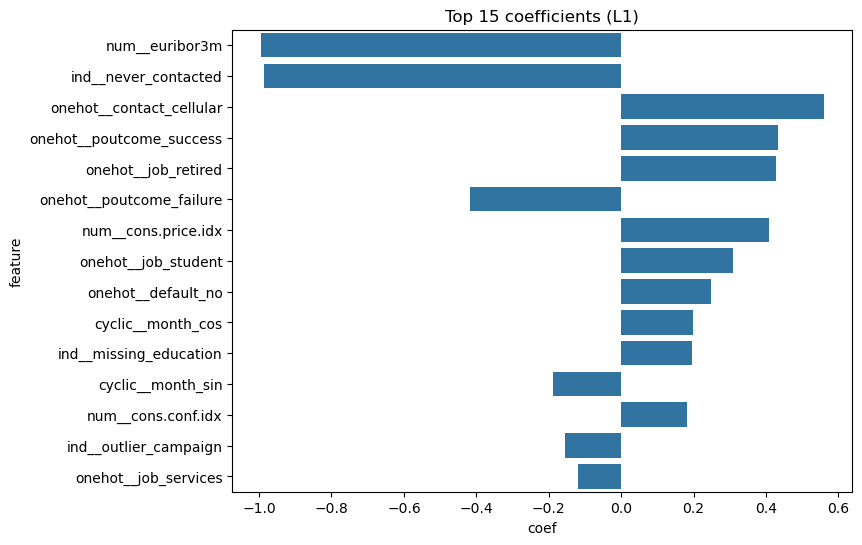

In [18]:
# --- 5. Coefficients L1 ---
coefs = model.named_steps["classifier"].coef_.ravel()
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs})
coef_df = coef_df.sort_values(by="coef", key=abs, ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x="coef", y="feature", data=coef_df.head(15))
plt.title("Top 15 coefficients (L1)")
plt.show()